In [40]:
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import torch_directml
import seaborn as sns

In [41]:
# 1) Input
# 2) CNN1 (8 filters, batch norm, ReLU)
# 3) Max pooling
# 4) CNN2 (32 filters with 8 subfilters, batch norm, ReLU)
# 5) Max pooling
# 6) FC1 (Flattening, ReLU)
# 7) FC2 (Output with 10 classes)

In [42]:
# Variables
mean_gray = 0.1307
stddev_gray = 0.3081
batch_size = 100
epochs = 10
max_errors = 10
train_loss = []
train_accuracy = []
test_loss = []
test_accuracy = []

In [43]:
# input[channel] = (input[channel] - mean[channel]) / stddev[channel]
transformer = transforms.Compose([transforms.ToTensor(),
                                  transforms.Normalize((mean_gray,),
                                                       (stddev_gray,))])
photo_transformer = transforms.Compose([transforms.Resize((28, 28)),
                                        transforms.Grayscale(num_output_channels=1),
                                        transforms.RandomInvert(p=1.0),
                                        transforms.ToTensor(),
                                        transforms.Normalize((mean_gray,), (stddev_gray,))])

In [44]:
# Datasets
train_dataset = datasets.MNIST(root='./source',
                               train=True,
                               transform=transformer,
                               download=True)
test_dataset = datasets.MNIST(root='./source',
                              train=False,
                              transform=transformer,
                              download=True)

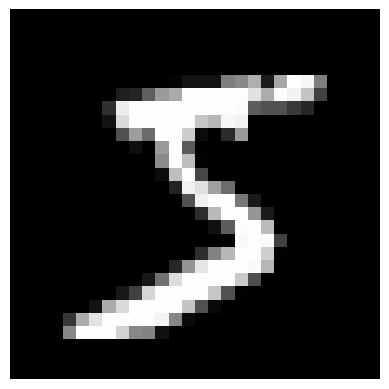

5


In [45]:
# Check
random_img = train_dataset[0][0] * stddev_gray + mean_gray
plt.axis('off')
plt.imshow(random_img.view(28, 28),
           cmap='gray')
plt.show()
print(train_dataset[0][1])

In [46]:
# Data loaders
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=batch_size,
                                           shuffle=False)

In [47]:
# Check
print(len(train_dataset))
print(len(test_dataset))

print()

print(len(train_loader))
print(len(test_loader))

60000
10000

600
100


In [48]:
# Model class
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn1 = nn.Conv2d(in_channels=1,
                              out_channels=8,
                              kernel_size=3,
                              stride=1,
                              padding=1)
        self.batch_norm1 = nn.BatchNorm2d(num_features=8)
        self.relu =  nn.ReLU()
        self.max_pool = nn.MaxPool2d(kernel_size=2)
        self.cnn2 = nn.Conv2d(in_channels=8,
                              out_channels=32,
                              kernel_size=5,
                              stride=1,
                              padding=2)
        self.batch_norm2 = nn.BatchNorm2d(num_features=32)
        self.fc1 = nn.Linear(in_features=7*7*32, out_features=600)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=600, out_features=10)
    def forward(self, x):
        # CNN1
        out = self.cnn1(x)
        out = self.batch_norm1(out)
        out = self.relu(out)
        # Max Pool 1
        out = self.max_pool(out)
        # CNN2
        out = self.cnn2(out)
        out = self.batch_norm2(out)
        out = self.relu(out)
        # Max Pool 2
        out = self.max_pool(out)
        # Flatten
        out = out.view(-1, 7*7*32)
        # FC1
        out = self.fc1(out)
        out = self.relu(out)
        # Dropout
        out = self.dropout(out)
        # FC2
        out = self.fc2(out)
        return out

In [49]:
# Initialization
model = CNN()
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
elif torch_directml.is_available():
   device = torch_directml.device()
   print(torch_directml.device_name(0))
else:
    device = torch.device("cpu")
    print("cpu")
model = model.to(device)
loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.SGD(model.parameters(),
                            lr=0.01,
                            momentum=0.9,
                            weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                            step_size=5,
                                            gamma=0.1)

AMD Radeon RX 6800S 


In [50]:
# All input tensors must have 4 dimentions (batch_size, channels, rows, columns)
# All labels have 1 dimention (batch_size) - answer
# All output tensors have 2 dimentions (batch_size, classes) - predicted probabilities for every class
# Maximum across all probabiliteis (dim=1) is the predicted class

In [51]:
# Learning
for epoch in range(epochs):
    model.train()
    correct = 0
    iterations = 0
    epoch_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Transfer
        inputs = inputs.to(device)
        labels = labels.to(device)
        # Predict
        outputs = model(inputs)
        # Loss
        loss = loss_fn(outputs, labels)
        epoch_loss += loss.item()
        # Bckprop
        optimizer.zero_grad()
        loss.backward()
        # Update
        optimizer.step()
        # Accuracy
        _, predictions = torch.max(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        iterations += 1
    # Update
    scheduler.step()
    # Accuracy
    train_loss.append(epoch_loss / iterations)
    train_accuracy.append(correct / len(train_dataset) * 100)

    # Testing
    model.eval()
    test_epoch_loss = 0.0
    correct = 0
    iterations = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            # Transfer
            inputs = inputs.to(device)
            labels = labels.to(device)
            # Predict
            outputs = model(inputs)
            # Loss
            loss = loss_fn(outputs, labels)
            test_epoch_loss += loss.item()
            # Accuracy
            _, predictions = torch.max(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            iterations += 1
    # Accuracy
    test_loss.append(test_epoch_loss / iterations)
    test_accuracy.append(correct / len(test_dataset) * 100)
    # Print loss and accuracy
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Training loss: {train_loss[-1]:.3f}   |   Training accuracy: {train_accuracy[-1]:.3f}")
    print(f"Testing loss: {test_loss[-1]:.3f}   |   Testing accuracy: {test_accuracy[-1]:.3f}")
    print()

Epoch 1/10
Training loss: 0.191   |   Training accuracy: 93.983
Testing loss: 0.046   |   Testing accuracy: 98.420

Epoch 2/10
Training loss: 0.064   |   Training accuracy: 98.095
Testing loss: 0.036   |   Testing accuracy: 98.670

Epoch 3/10
Training loss: 0.047   |   Training accuracy: 98.585
Testing loss: 0.035   |   Testing accuracy: 98.770

Epoch 4/10
Training loss: 0.039   |   Training accuracy: 98.747
Testing loss: 0.028   |   Testing accuracy: 99.100

Epoch 5/10
Training loss: 0.034   |   Training accuracy: 98.930
Testing loss: 0.025   |   Testing accuracy: 99.180

Epoch 6/10
Training loss: 0.022   |   Training accuracy: 99.323
Testing loss: 0.022   |   Testing accuracy: 99.270

Epoch 7/10
Training loss: 0.019   |   Training accuracy: 99.483
Testing loss: 0.022   |   Testing accuracy: 99.220

Epoch 8/10
Training loss: 0.018   |   Training accuracy: 99.455
Testing loss: 0.022   |   Testing accuracy: 99.260

Epoch 9/10
Training loss: 0.018   |   Training accuracy: 99.485
Testing 

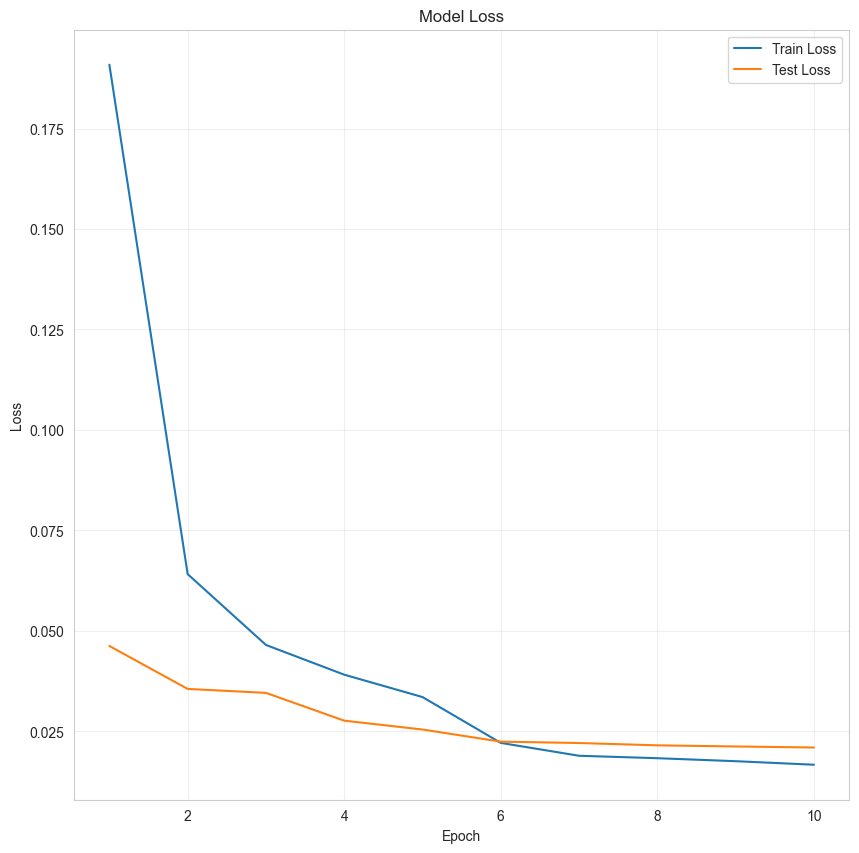

In [52]:
# Plotting loss
plt.figure(figsize=(10, 10), dpi=100)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.grid(True, alpha=0.3)
sns.lineplot(x=range(1, len(train_loss)+1), y=train_loss, label='Train Loss')
sns.lineplot(x=range(1, len(test_loss)+1), y=test_loss, label='Test Loss')
plt.legend()
plt.show()

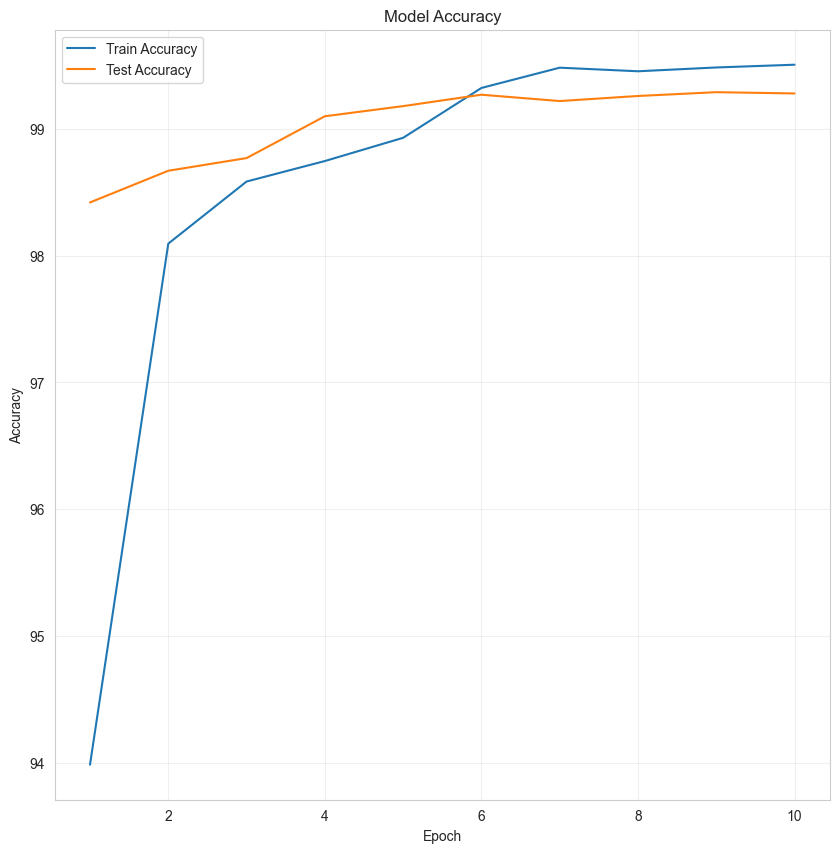

In [53]:
# Plotting accuracy
plt.figure(figsize=(10, 10), dpi=100)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.grid(True, alpha=0.3)
sns.lineplot(x=range(1, len(train_accuracy)+1), y=train_accuracy, label='Train Accuracy')
sns.lineplot(x=range(1, len(test_accuracy)+1), y=test_accuracy, label='Test Accuracy')
plt.legend()
plt.show()

Testing the model

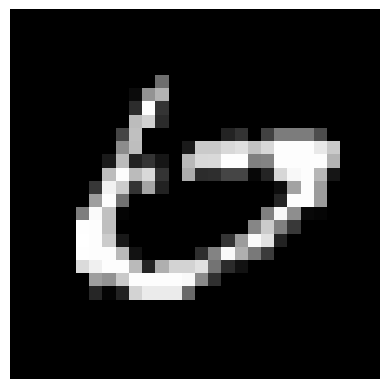

Predicted value: 0
Actual value: 6


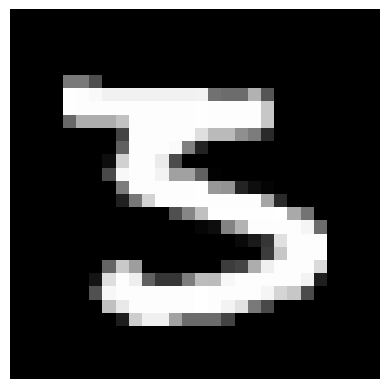

Predicted value: 5
Actual value: 3


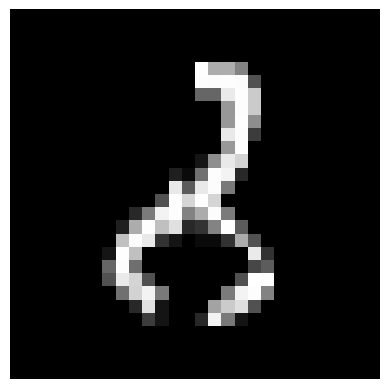

Predicted value: 2
Actual value: 8


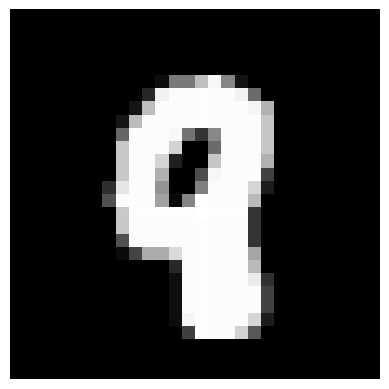

Predicted value: 9
Actual value: 8


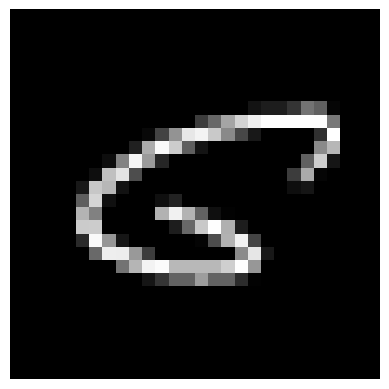

Predicted value: 5
Actual value: 6


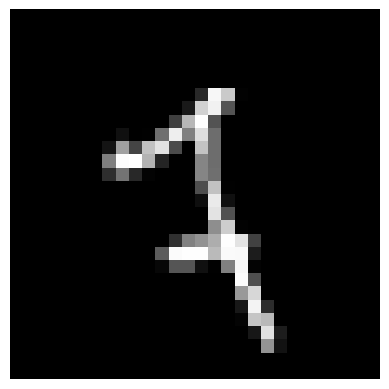

Predicted value: 2
Actual value: 7


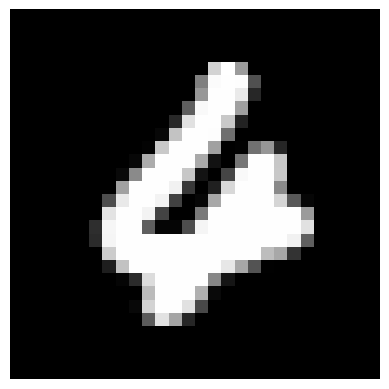

Predicted value: 6
Actual value: 4


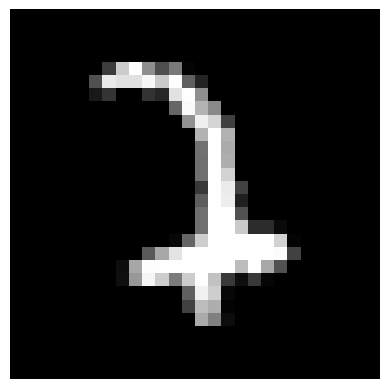

Predicted value: 2
Actual value: 7


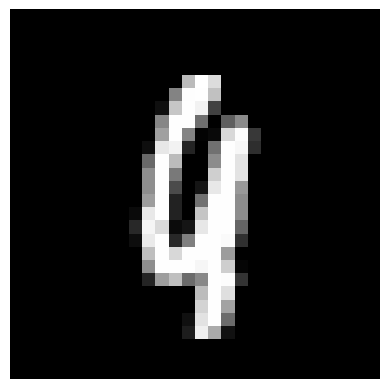

Predicted value: 4
Actual value: 9


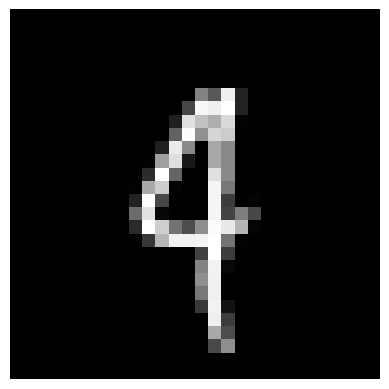

Predicted value: 9
Actual value: 4


In [54]:
# Testing
model.eval()
errors = 0
with torch.no_grad():
    for image, label in test_dataset:
        image = image.unsqueeze(0).to(device)
        output = model(image)
        _, prediction = torch.max(output, dim=1)
        if label != prediction.item():
            plt.axis('off')
            plt.imshow(image.cpu().view(28, 28) * stddev_gray + mean_gray, cmap='gray')
            plt.show()
            print(f"Predicted value: {prediction.item()}")
            print(f"Actual value: {label}")
            errors += 1
            if errors >= max_errors:
                break

Testing on my own images

In [66]:
# Predict function
def predict(model, img_path):
    model.eval()
    image = Image.open(img_path)
    plt.axis('off')
    plt.imshow(image, cmap='gray')
    image = photo_transformer(image).unsqueeze(0).to(device)
    plt.show()
    plt.axis('off')
    plt.imshow(image.cpu().view(28, 28) * stddev_gray + mean_gray, cmap='gray')
    plt.show()
    output = model(image)
    _, prediction = torch.max(output, dim=1)
    return prediction.item()

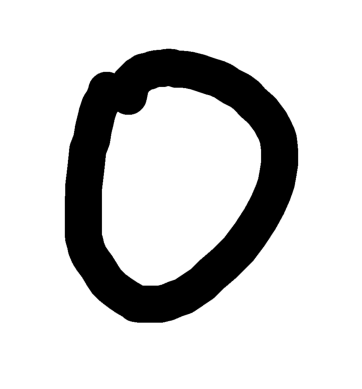

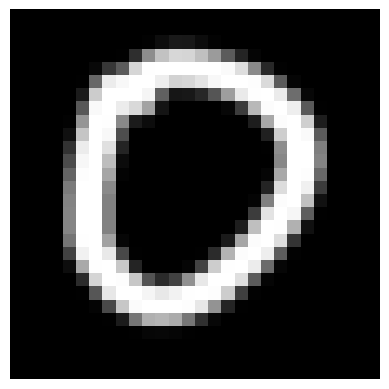

0


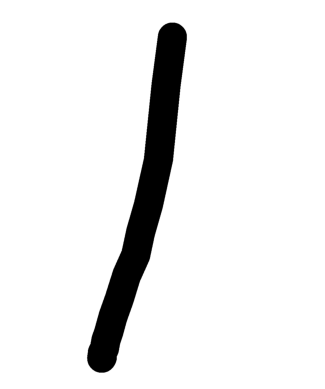

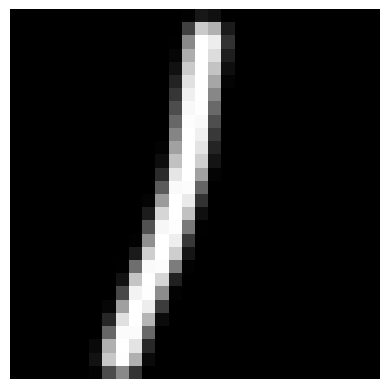

1


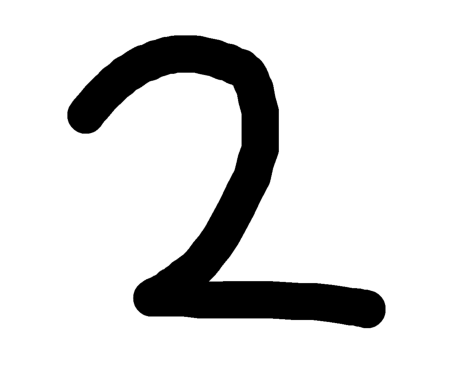

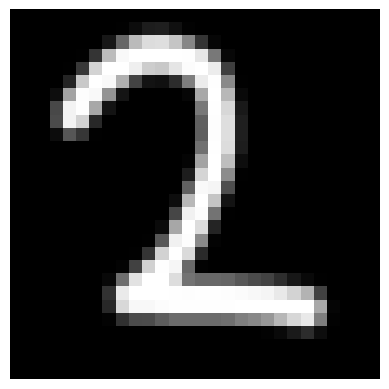

2


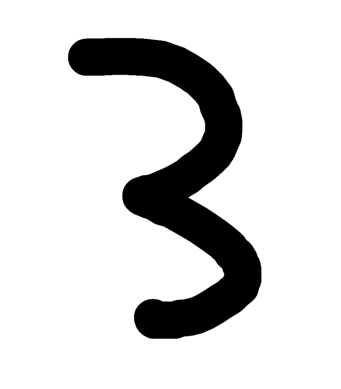

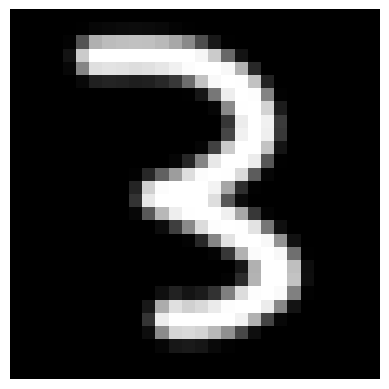

3


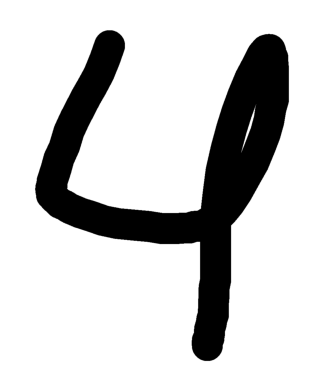

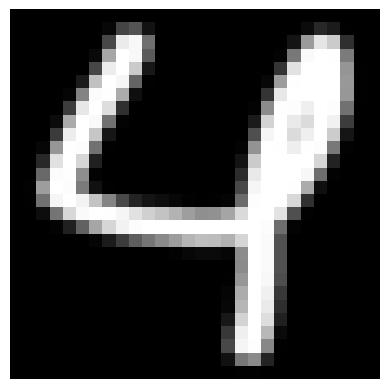

4


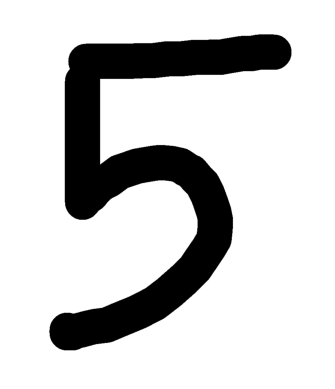

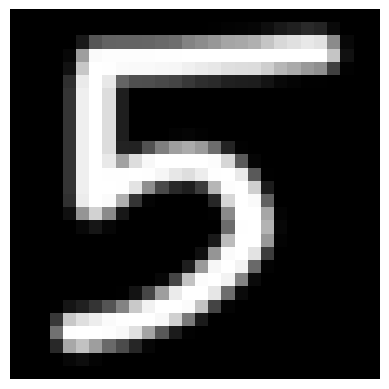

5


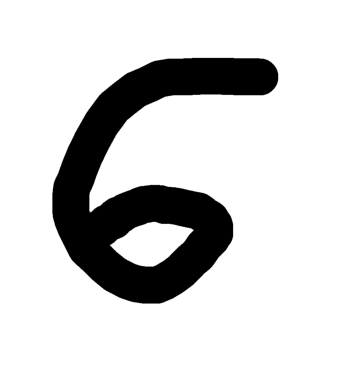

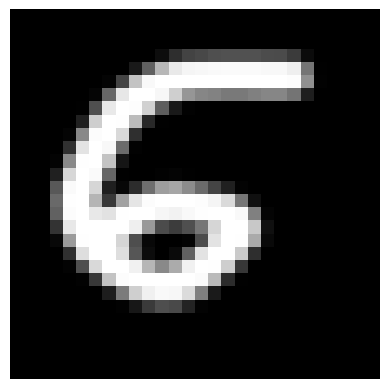

5


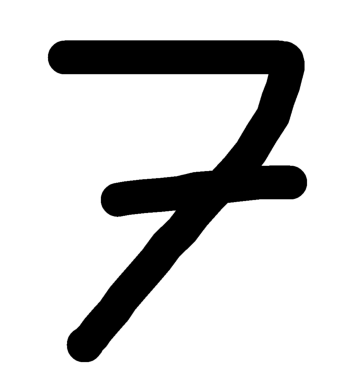

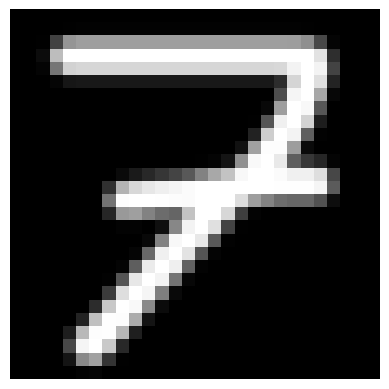

7


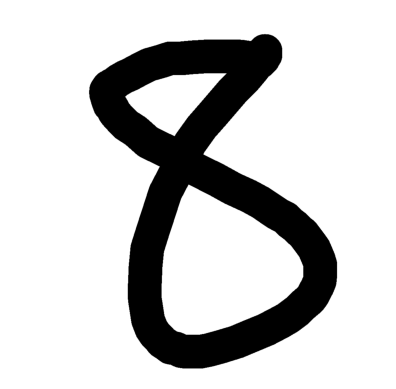

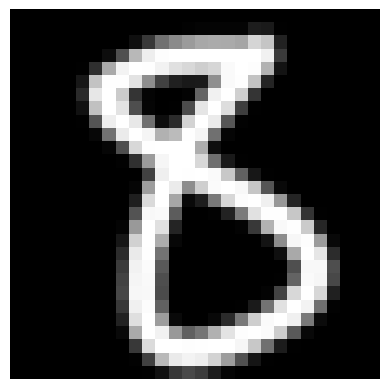

8


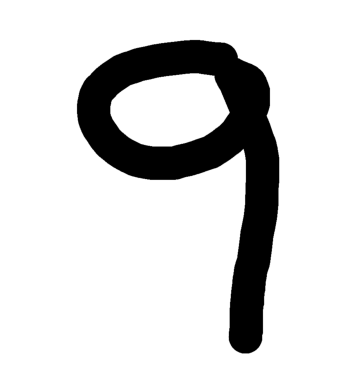

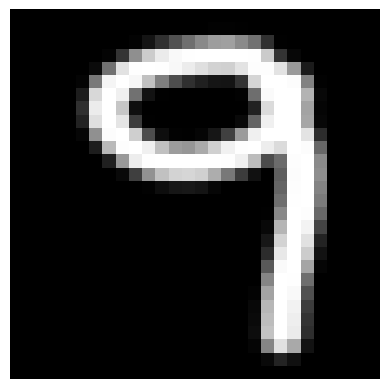

9


In [67]:
# Check
prediction = predict(model, "./source/images/zero.png")
print(prediction)
prediction = predict(model, "./source/images/one.png")
print(prediction)
prediction = predict(model, "./source/images/two.png")
print(prediction)
prediction = predict(model, "./source/images/three.png")
print(prediction)
prediction = predict(model, "./source/images/four.png")
print(prediction)
prediction = predict(model, "./source/images/five.png")
print(prediction)
prediction = predict(model, "./source/images/six.png")
print(prediction)
prediction = predict(model, "./source/images/seven.png")
print(prediction)
prediction = predict(model, "./source/images/eight.png")
print(prediction)
prediction = predict(model, "./source/images/nine.png")
print(prediction)